In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/starbucks.csv')

# Display the first few rows of the DataFrame
display(df.head())

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0%,0%,0%,0%,175
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0%,0%,0%,0%,260
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,0%,0%,330
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,2%,0%,410
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10%,0%,20%,0%,75


# New section

Now, let's identify the drink with the highest calories and visualize it using a pie chart.

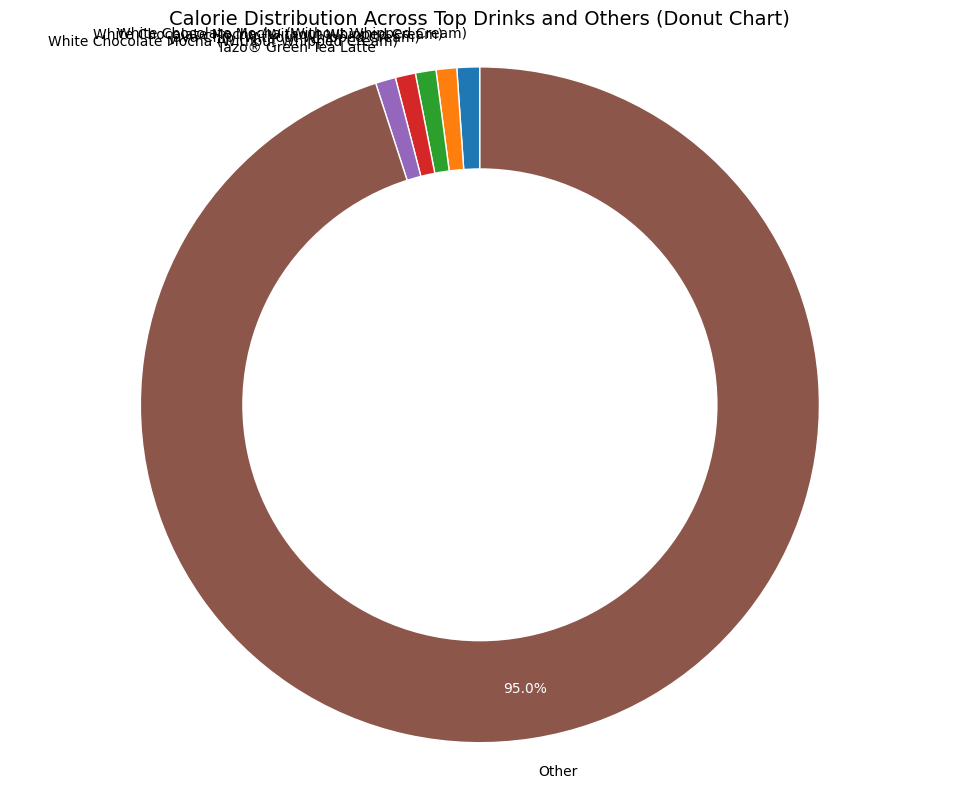

The drink with the highest calories is: White Chocolate Mocha (Without Whipped Cream) with 510 calories.


In [7]:
# Find the drink with the highest calories
highest_calorie_drink = df.loc[df['Calories'].idxmax()]

# Prepare data for the pie chart
# We'll show the top N drinks by calories and group the rest as 'Other'
num_top_drinks = 5
top_drinks = df.nlargest(num_top_drinks, 'Calories')
other_calories = df['Calories'].sum() - top_drinks['Calories'].sum()

pie_data = top_drinks[['Beverage', 'Calories']].set_index('Beverage')

if other_calories > 0:
    pie_data.loc['Other'] = other_calories

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    pie_data['Calories'],
    labels=pie_data.index,
    autopct=lambda p: '{:.1f}%'.format(p) if p > 5 else '', # Only show percentages for slices > 5%
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='w') # Donut chart style
)

# Set colors for the percentage labels (autotexts)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

# Draw a circle in the middle to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Calorie Distribution Across Top Drinks and Others (Donut Chart)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"The drink with the highest calories is: {highest_calorie_drink['Beverage']} with {highest_calorie_drink['Calories']} calories.")

Now, let's visualize the average calories per beverage category using a bar chart.

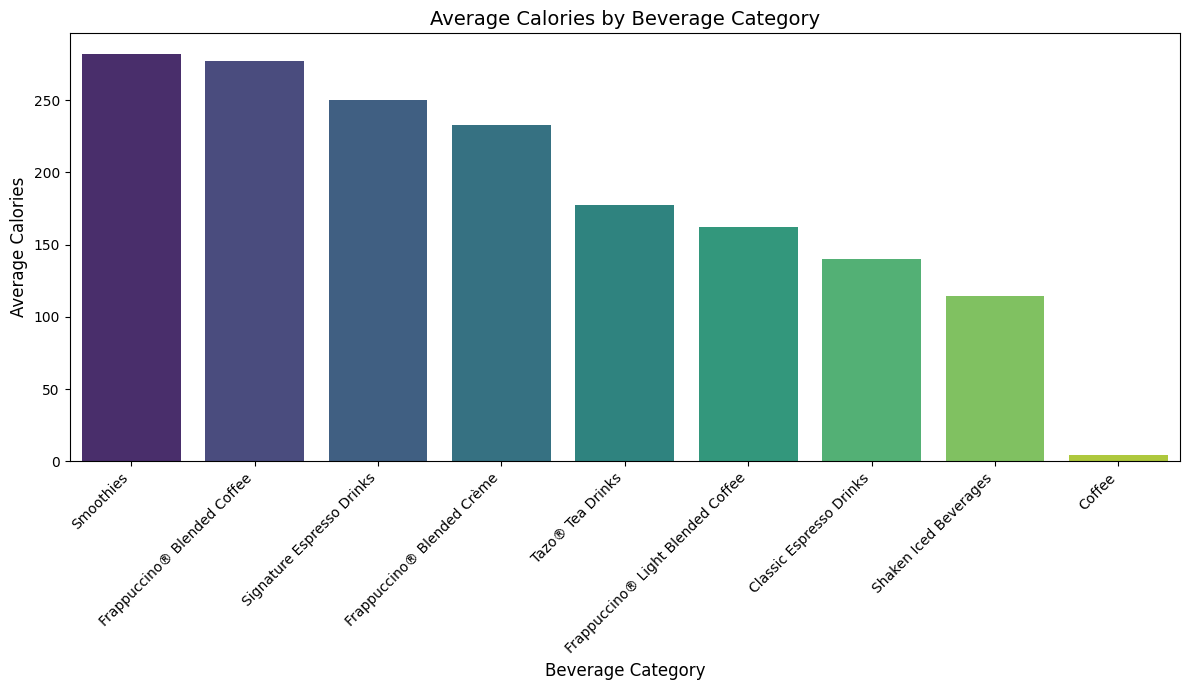

In [8]:
# Calculate the average calories for each beverage category
average_calories_by_category = df.groupby('Beverage_category')['Calories'].mean().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=average_calories_by_category.index, y=average_calories_by_category.values, hue=average_calories_by_category.index, palette='viridis', legend=False)

plt.xlabel('Beverage Category', fontsize=12)
plt.ylabel('Average Calories', fontsize=12)
plt.title('Average Calories by Beverage Category', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Distribution of Beverage Categories

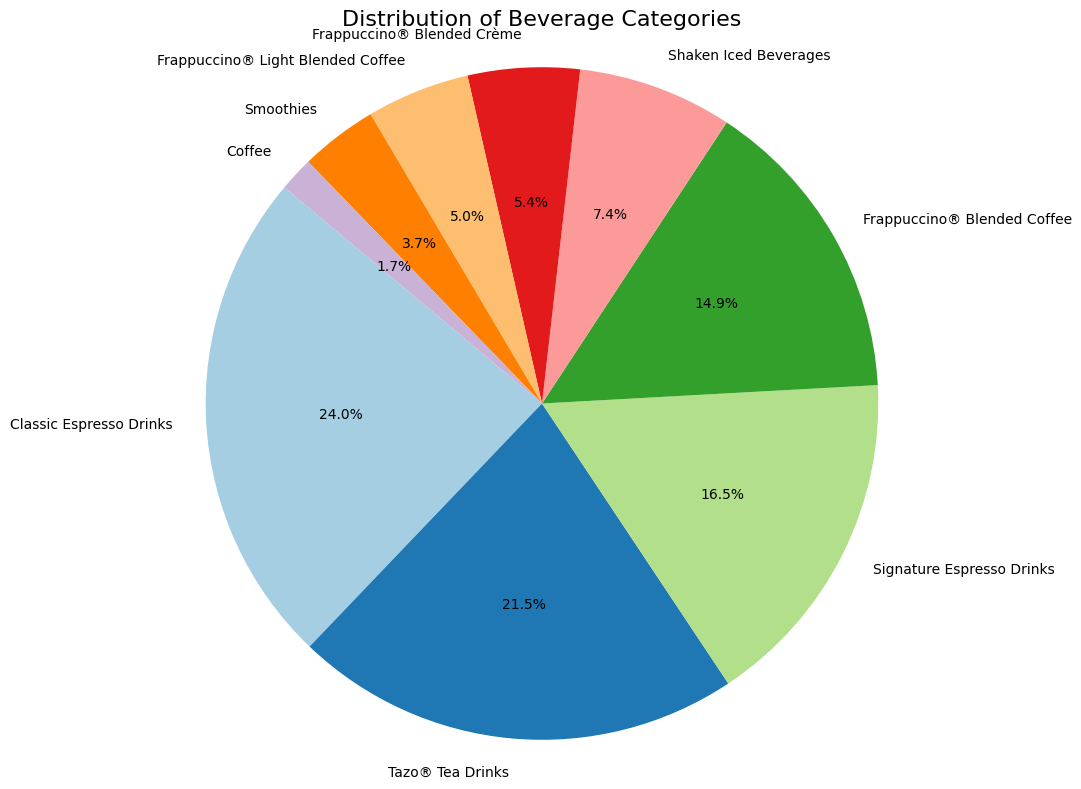

In [9]:
category_counts = df['Beverage_category'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Beverage Categories', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

Now, let's prepare the data for an LSTM model. We'll convert 'Calories' into a categorical target variable ('Calorie_Level') for a classification task, preprocess other numerical features, and then split the data for training and testing.

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score

# Make a copy to avoid modifying the original DataFrame
df_model = df.copy()

# Clean column names by stripping whitespace
df_model.columns = df_model.columns.str.strip()

# --- 1. Data Cleaning and Feature Engineering ---

# Convert percentage columns from string ('X%') to float (0.XX)
percentage_cols = [
    'Vitamin A (% DV)', 'Vitamin C (% DV)', 'Calcium (% DV)', 'Iron (% DV)'
]
for col in percentage_cols:
    # Handle non-numeric values by coercing errors to NaN
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col].astype(str).str.replace('%', ''), errors='coerce') / 100

# Handle 'Caffeine (mg)' column
# Replace 'Varies' with NaN and convert to numeric
if 'Caffeine (mg)' in df_model.columns:
    # Convert to string, then lowercase, then replace 'varies' and convert to float
    df_model['Caffeine (mg)'] = df_model['Caffeine (mg)'].astype(str).str.lower().replace('varies', np.nan).astype(float)

# Fill remaining NaNs in numerical columns with the mean of their respective columns
# (After converting percentages and handling 'Varies')
numerical_cols = df_model.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].mean())

# Define features (X) and target (y)
# We will use all numerical columns except 'Calories' as features
feature_cols = [col for col in numerical_cols if col != 'Calories']
X = df_model[feature_cols]

# Create a categorical 'Calorie_Level' target for classification
# Bin 'Calories' into 3 levels: Low, Medium, High
df_model['Calorie_Level'] = pd.qcut(
    df_model['Calories'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Encode categorical target labels to numerical values (0, 1, 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model['Calorie_Level'])

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Calorie Levels and their mapping:", list(label_encoder.classes_), list(label_encoder.transform(label_encoder.classes_)))


Original X shape: (242, 13)
Original y shape: (242,)
Calorie Levels and their mapping: ['High', 'Low', 'Medium'] [np.int64(0), np.int64(1), np.int64(2)]


Next, we'll scale the features and reshape the data for the LSTM model. Since each drink is an independent sample, we'll use a `timesteps` value of 1, effectively treating the features of each drink as a sequence of length one.

In [11]:
# --- 2. Data Scaling and Reshaping ---

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM (samples, timesteps, features)
# For non-time-series data, we can set timesteps=1
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

print("Scaled and reshaped X shape:", X_reshaped.shape)

Scaled and reshaped X shape: (242, 1, 13)


Now, we'll split the preprocessed data into training and testing sets with an 80:20 ratio.

In [12]:
# --- 3. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (193, 1, 13)
X_test shape: (49, 1, 13)
y_train shape: (193,)
y_test shape: (49,)


Finally, we will build, compile, and train our LSTM model, and then evaluate its accuracy on the test set.

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,953 (50.60 KB)

 Trainable params: 12,953 (50.60 KB)

 Non-trainable params: 0 (0.00 B)

Model training complete.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Test Accuracy: 0.8776


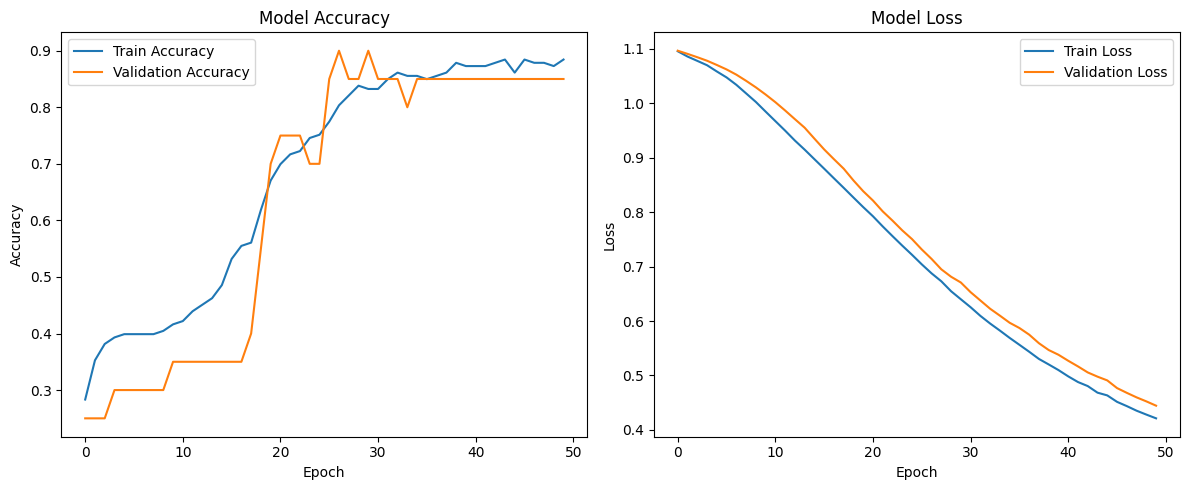

In [13]:
# --- 4. Build and Train LSTM Model ---

# Determine the number of classes for the output layer
num_classes = len(np.unique(y_train))

model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model Summary:")
model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)

print("Model training complete.")

# --- 5. Evaluate Model ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Optional: Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix for Calorie Level Prediction

Let's visualize the model's performance using a confusion matrix. This will show us where the model made correct and incorrect predictions for each calorie level (Low, Medium, High).

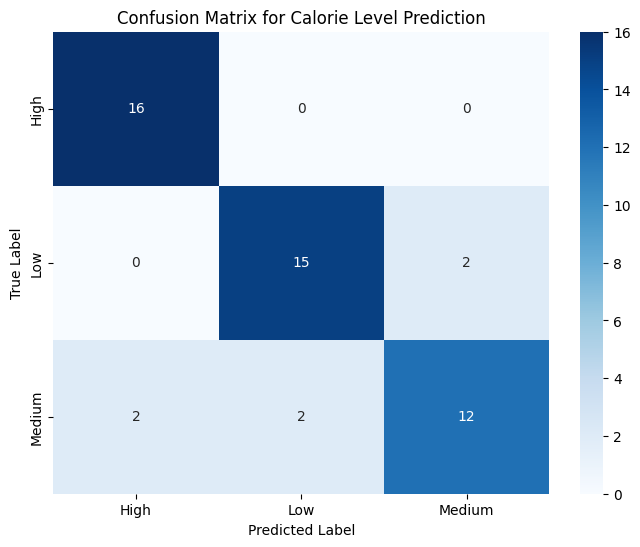

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the class labels from the label_encoder
class_names = label_encoder.classes_ # This is 'High', 'Low', 'Medium'

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Calorie Level Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Actual vs. Predicted Calorie Levels (Test Set)

Let's view a table comparing the true calorie levels with the model's predictions for the test set samples.

In [15]:
# Map numerical predictions back to original labels
actual_labels = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform(y_pred)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({'Actual Calorie Level': actual_labels, 'Predicted Calorie Level': predicted_labels})

# Display the comparison table
display(comparison_df.head(10)) # Displaying first 10 for brevity

,Actual Calorie Level,Predicted Calorie Level
0,High,High
1,High,High
2,High,High
3,Low,Low
4,High,High
5,Medium,Medium
6,Medium,High
7,Medium,Medium
8,Low,Low
9,Low,Low


### Save the Trained LSTM Model

Let's save the trained model so it can be loaded and used later without needing to retrain.

In [16]:
# Save the entire model (architecture, optimizer, weights, etc.)
model.save('lstm_calorie_model.h5')
print("Model saved to lstm_calorie_model.h5")

Model saved to lstm_calorie_model.h5
